## Lab Exercise Week \#2: k-Nearest Neighbors (kNN) in Machine Learning

### Objective:
The goal of this lab exercise is to understand the k-Nearest Neighbors (kNN) algorithm and its application in machine learning. You will implement kNN on a dataset, tune hyperparameters, and evaluate model performance.

### Dataset:
For this lab exercise, you'll use the famous Iris dataset (importable throigh sklearn library in python), which contains measurements of various features of iris flowers.

### Tasks:

#### 1). Data Loading and Exploration:
<ul>
<li>Load the Iris dataset.</li>
<li>Explore the dataset to understand its structure and features.</li>
<li>Visualize the data using scatter plots or any other suitable visualization method.</li>
</ul>

In [ ]:
# Import necessary libraries
import numpy as np # data manipulation
import pandas as pd # data manipulation
import matplotlib.pyplot as plt # viausliation
from sklearn.datasets import load_iris # dataset
from sklearn.model_selection import train_test_split # model selection package usign train and test functin from it
from sklearn.preprocessing import StandardScaler # normalisation used to normalise the data
from sklearn.metrics import accuracy_score, classification_report # metrics for evaluation of mdoel accuracy and class repor
from sklearn.neighbors import KNeighborsClassifier # knn classifier built in implemetnation of classifier

# Task 1: Data Loading and Exploration
iris = load_iris()
# loads data using fn
data = pd.DataFrame(data= np.c_[iris['data'], iris['target']], columns= iris['feature_names'] + ['target'])

# set features in the df > build df features = usig name of df using column data
# 4 values in side it + target
# features are in iris data and target will be set in iris target = output of model
# feature_names + target  >>> cal it what uyou like .... ie. feature x ot y as target...
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [17]:
print(f"dataset details , {data.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    float64
dtypes: float64(5)
memory usage: 6.0 KB
dataset details , None


In [21]:
print("\n Target Variables Distribution: \n ", data['target'].value_counts())


 Target Variables Distribution: 
  target
0.0    50
1.0    50
2.0    50
Name: count, dtype: int64


#### 2). Data Preprocessing:

<ul>
<li>Split the dataset into training and testing sets.</li>
<li>Normalize the features if necessary.</li>
<li>Print the shapes of train and target variables.</li>
</ul>

In [ ]:
# Task 2: Data Preprocessing
# name of DF and iloc - number of samples
X = data.iloc[:, :-1].values # all the samples inside the data..-1 is number of column needed . 1st four columns and leave last column... in case dataset has 6 columns, take first 5 and leave last one... x wills tore values of first 4 features in the dataset
y = data.iloc[:, -1].values # last column will eb save din this value... y...
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 80% for train and 20% for test > random state is to reproducibility of model... random value... 
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
# traing and testig 
# y_train and y_test  = is no column.. just one columns... just number of samples for each on....
# just the number of the sampls for each one...alreafy one column... will nto find a vlaue here...
#

(120, 4) (30, 4) (120,) (30,)


In [ ]:
# normalise the data set can use min/max or standard scaler
# feed trainign data for 
# d same for X_test
# we use fit_tranfrom only for X_tra
# standard scalr is applied 
# Stndard Scalar => gets 2 thigns from data mean + STd Dev
sc=StandardScaler() # craetes a standard scalr instance
X_train=sc.fit_transform(X_train) # fits the scalar to the X_train set, training data, then  transforms it..
X_test=sc.transform(X_test) # transforms the test data using the SAME fitted scaler

# Key point: It's intentional and important that fit_transform() is used on training data but only transform() on test 
# data. Using fit_transform() on test data would be a data leakage mistake, as it would calculate new mean/standard # # # # deviation from the test set rather than applying the training set's scaling parameters.
# >> training data >> let scaler learn and apply thw scaling (fit_transfor)
# >> test data >> only apply the scaling it has already learned (transform) (( fon't let model learn from test data too.... this is "data leakage".... and makes model look better than it actually is))


### 3). Implement k-Nearest Neighbors:
<ul>
<li>Write a Python function to implement the kNN algorithm.</li>
<li>Allow users to specify the value of 'k' as a parameter.</li>
<li>Use Euclidean distance as the distance metric.</li>
</ul>

In [27]:
# Task 3: Implement k-Nearest Neighbors# 1st step -- define the function....
def knn_predict(X_train, y_train, X_test, k): # need 3 values for parameters... 
    predictions = [] # build list that will ahve predictuins for each k value yuo will ahve
    for test_instance in X_test: # for loop for computing the euclidean distance # do for each instance in x test...
        distances = np.linalg.norm(X_train - test_instance, axis=1) # np.linalg used to compute the euclidean distance
        nearest_neighbors = np.argsort(distances)[:k] # np.argument sort - used to sort values o distance that we have..ca;culaye NN for each instance in X test
        neighbor_labels = y_train[nearest_neighbors] # use name of y_train . calcualted based on valeus of NN 
        unique_labels, counts = np.unique(neighbor_labels, return_counts=True) # unique counts// used o find unique lables among neighbours based on their apparance inside each cluster...
        predicted_label = unique_labels[np.argmax(counts)] # predicted label lavel with highest count... the ptedicted label...get max number of apparances of one class... the rpedicted class.. the predicted label .fn to get max value.. which class that this belongs to
        predictions.append(predicted_label) # append value to list
    return np.array(predictions) # convert from list to array....

#### 4). Model Training:
<ul>
    <li>Train the kNN model on the training set by calling the defined function above.</li>
</ul>

In [28]:
# Task 4: Model Training
# use k value as 7
k_value = 7
y_pred = knn_predict(X_train, y_train, X_test, k_value) # function from earlier

#### 5). Hyperparameter Tuning:

<ul>
    <li>Experiment with different values of 'k' (e.g., k=3, 5, 7) and observe how it affects the model's performance.</li>
    <li>Plot a graph showing the accuracy for different values of 'k' and choose the optimal 'k' for the model.</li>
</ul>

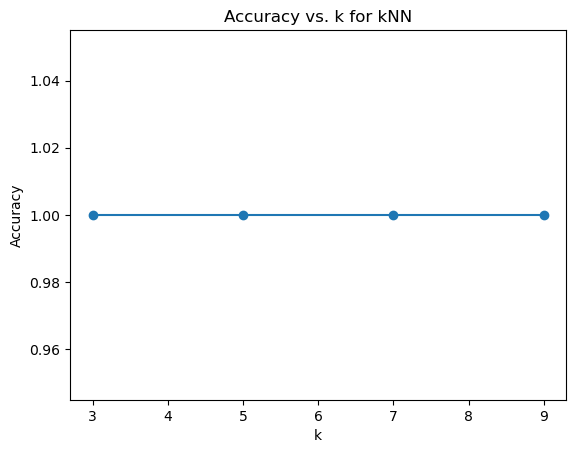

In [ ]:
# Task 5: Hyperparameter Tuning
# experiemnt with different values to see hwo different values of k 
# lower may over fit
# higher valeus under fit

k_values = [3, 5, 7, 9] # create a list with different values array with different values of k
accuracy_values = [] # list for output for each value fo k

for k in k_values: # for loop for each of the k values
    y_pred = knn_predict(X_train, y_train, X_test, k) # call funtion and pass 
    accuracy = accuracy_score(y_test, y_pred) # call other values again.. y_test... actual values in test set... 
    accuracy_values.append(accuracy) # compute accuracy using ccuracy score function - alresdy imported... pass y_test and y_prediction...

# Plotting accuracy vs. k
plt.plot(k_values, accuracy_values, marker='o') # 
plt.title('Accuracy vs. k for kNN') # title
plt.xlabel('k') # label x axis
plt.ylabel('Accuracy') # label y axis
plt.show()

#### 6). Model Evaluation:

<ul>
    <li>Use the trained model to make predictions on the testing set.</li>
    <li>Evaluate the model's performance using metrics such as accuracy, precision, recall, and F1-score.</li>
</ul>

In [ ]:
# Task 6: Model Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))

f1 a; of them is 1.. means model is workign very good...

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        10
         1.0       1.00      1.00      1.00         9
         2.0       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#### 7). Visualization:

<ul>
    <li>Visualize the decision boundaries of the kNN classifier on a 2D plot. You can choose two features for this purpose.</li>
</ul>


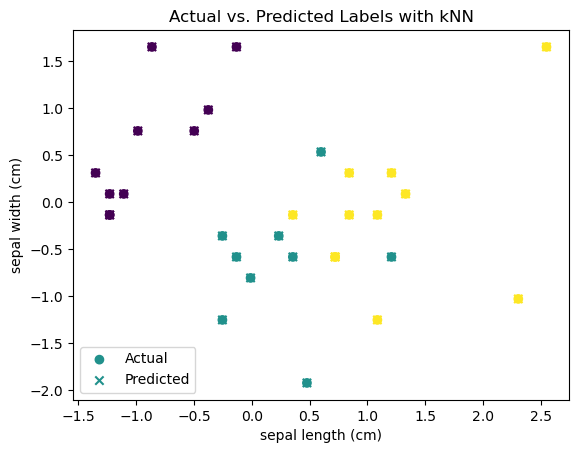

In [ ]:
# Task 7: Visualization
# Choose two features for visualization
feature1_index = 0 # onyl use two features.... used to provide a good separation in the iris dataset...
feature2_index = 1 # petal length and petal width (number 2)

# can dop colourign for each point
# use scatterplot
# all the samples just for feature2_index
# all the samples just for feature2_index
# using y_test >>> its actual data


plt.scatter(X_test[:, feature1_index], X_test[:, feature2_index], c=y_test, cmap='viridis', label='Actual')
plt.scatter(X_test[:, feature1_index], X_test[:, feature2_index], c=y_pred, cmap='viridis', marker='x', label='Predicted')


plt.xlabel(iris.feature_names[feature1_index]) # define x labela s featurws if iris dataset x axis = feature # 1
plt.ylabel(iris.feature_names[feature2_index]) # y axis = feature # 2 (can do for feature 3 and 4...)
plt.legend()
plt.title('Actual vs. Predicted Labels with kNN')
plt.show()

### claude
plt.scatter(X_test[:, feature1_index], X_test[:, feature2_index], c=y_test, cmap='viridis', label='Actual')
plt.scatter(X_test[:, feature1_index], X_test[:, feature2_index], c=y_pred, cmap='viridis', marker='x', label='Predicted')


plt.xlabel(iris.feature_names[feature1_index]) # define x labela s featurws if iris dataset x axis = feature # 1
plt.ylabel(iris.feature_names[feature2_index]) # y axis = feature # 2 (can do for feature 3 and 4...)
plt.legend()
plt.title('Actual vs. Predicted Labels with kNN')
plt.show()

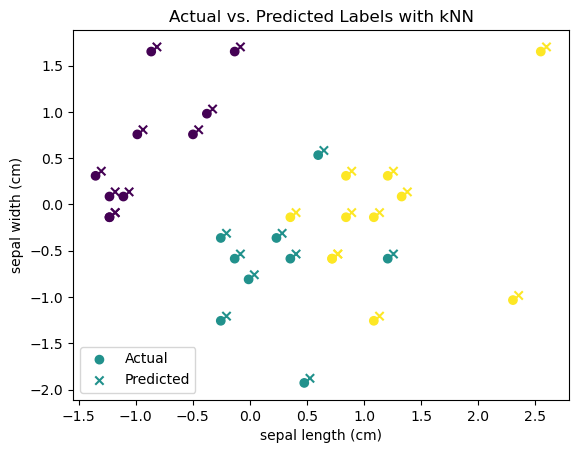

In [32]:
offset = 0.05  # small nudge so predicted markers are visible

plt.scatter(X_test[:, feature1_index], X_test[:, feature2_index], 
            c=y_test, cmap='viridis', label='Actual')

plt.scatter(X_test[:, feature1_index] + offset, X_test[:, feature2_index] + offset, 
            c=y_pred, cmap='viridis', marker='x', label='Predicted')

### claude
# plt.scatter(X_test[:, feature1_index], X_test[:, feature2_index], c=y_test, cmap='viridis', label='Actual')
# plt.scatter(X_test[:, feature1_index], X_test[:, feature2_index], c=y_pred, cmap='viridis', marker='x', label='Predicted')

plt.xlabel(iris.feature_names[feature1_index]) # define x labela s featurws if iris dataset x axis = feature # 1
plt.ylabel(iris.feature_names[feature2_index]) # y axis = feature # 2 (can do for feature 3 and 4...)
plt.legend()
plt.title('Actual vs. Predicted Labels with kNN')
plt.show()

The colours represent the **3 Iris species classes**, not actual vs predicted.
The `viridis` colourmap maps the 3 class labels (0, 1, 2) to colours:

| Colour | Class | Iris Species |
|--------|-------|-------------|
| Purple/Dark | 0 | Iris Setosa |
| Teal/Green | 1 | Iris Versicolor |
| Yellow | 2 | Iris Virginica |

So for **each colour** there is:
- `•` = actual label
- `×` = predicted label

**To spot misclassifications** — look for a `×` that is a **different colour** from its nearby `•`.
For example if you see a yellow `×` sitting near a teal `•`, that means the model predicted
Virginica but the actual was Versicolor.

From this plot, most `•` and `×` match in colour, which is consistent with an accuracy score
of 1.0 for k=3,5,7,9 — meaning the model predicted all test samples correctly.

#### 8). Discussion:
<ul>
    <li>Reflect on the impact of the choice of 'k' on the model's performance.</li>
    <li>Discuss situations where kNN might be a suitable or unsuitable algorithm.</li>
</ul>

In [8]:
# Task 8: Discussion
print("Discussion:")
print("1. The choice of 'k' significantly affects the model's performance. It's crucial to tune 'k' based on the dataset.")
print("2. Smaller 'k' values may lead to overfitting, while larger 'k' values may result in underfitting.")
print("3. kNN is suitable for datasets with clear decision boundaries and may not perform well on high-dimensional data.")

Discussion:
1. The choice of 'k' significantly affects the model's performance. It's crucial to tune 'k' based on the dataset.
2. Smaller 'k' values may lead to overfitting, while larger 'k' values may result in underfitting.
3. kNN is suitable for datasets with clear decision boundaries and may not perform well on high-dimensional data.


In [ ]:
# if use different normalisation method  >> may be accuracy will be different
# sometime small values of k get high variance and no bias
# model si sensitieve to noise..
# model cna generalise betetr but cna over fit or under fit based on value of k
# sometime low performance in generalisation because the orediction of knn classifier is influenced too mjuch by individual neightbours in case where it is very small...
# ' knn is very good classifier for clear decision on boundaries... but cannto perform well if high dimensional data i.e. # # too many features i.e > than o10 r there abouts...
# for iris dataset features and one target is good - decision boundaries are very clear
# when try 3, 5, 7, 9 accuracy is 1


#--- from claude
# value of k controls how many neighbours vote on a prediction - it is the most important hyperparameter kNN
# Small k (e.g. k=1, k=3) — the model listens to very few neighbours, making it sensitive to noise and individual data points, leading to high variance / overfitting
# Large k — the model averages over too many neighbours, losing local detail, leading to underfitting
# For the Iris dataset, k=3,5,7,9 all gave accuracy=1.0 because the decision boundaries are very clean and well-separated

About Your Plot

Where • (actual) and × (predicted) overlap = correct prediction
Where they don't overlap = misclassification
The scaled axes (negative values) confirm your StandardScaler was applied correctly

| Suitable | Unsuitable |
|----------|------------|
| Clear decision boundaries (like Iris) | High-dimensional data (many features, 10+) |
| Small-to-medium sized datasets | Large datasets (slow prediction time) |
| Low number of features | Noisy data with outliers |
| No assumption about data distribution | Imbalanced class distributions |